In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

plt.rcParams.update({
    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Fonts
    "font.size": 14,          # base font size
    "axes.titlesize": 16,     # title
    "axes.labelsize": 16,     # x,y labels

    # Tick labels
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    # Legend
    "legend.fontsize": 13,
    "legend.frameon": False,

    # Lines
    "lines.linewidth": 2,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.3,

    # Better layout
    "figure.autolayout": True,

    "text.usetex": False,   # set True if LaTeX installed
    "font.family": "serif",
    "mathtext.fontset": "stix",
})

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [4]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [5]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [6]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [7]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [8]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t



# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.9 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.9 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 389.4856114476723
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.8999999999999999
Minimum voltage after headroom scaling: 0.9516993402398705
Available headroom at peak (pu): 0.10000000000000009
Available headroom at peak (kW): 43.276179049741245


### EV Charging Dataset (Norway)

In [9]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_12808\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


### Base and EV data visualization

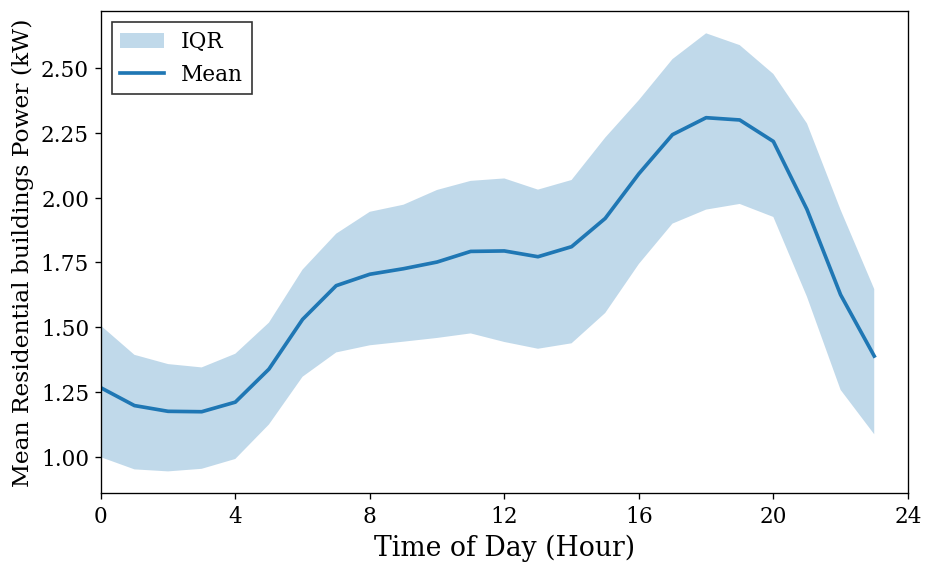

In [11]:
base_load = bus_load_kw_final.mean(axis=1)

def hourly_mean_iqr(series):
    df = pd.DataFrame({"value": series})
    df["hour"] = df.index.hour

    stats = df.groupby("hour")["value"].agg([
        ("q25", lambda x: np.percentile(x, 25)),
        ("mean", "mean"),
        ("q75", lambda x: np.percentile(x, 75)),
    ])
    return stats

res_stats = hourly_mean_iqr(base_load)

# Residential power plot
plt.figure(figsize=(8, 5))
h = res_stats.index.to_numpy()
m = res_stats["mean"].to_numpy()
q25 = res_stats["q25"].to_numpy()
q75 = res_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Mean Residential buildings Power (kW)", fontsize=14)
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


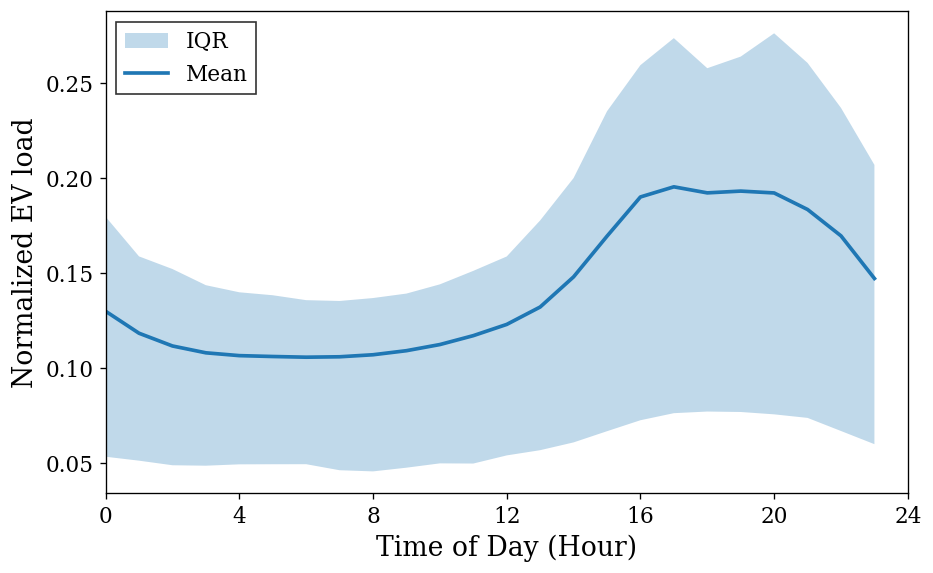

In [12]:
ev_df_plot = ev_df.copy()
ev_df_plot['Synthetic_7_2kW'] = ev_df_plot['Synthetic_7_2kW']/ev_df_plot['Synthetic_7_2kW'].max()

ev_stats = hourly_mean_iqr(ev_df_plot['Synthetic_7_2kW']) 

# Residential power plot
plt.figure(figsize=(8, 5))
h = ev_stats.index.to_numpy()
m = ev_stats["mean"].to_numpy()
q25 = ev_stats["q25"].to_numpy()
q75 = ev_stats["q75"].to_numpy()

plt.fill_between(h, q25, q75, alpha=0.28, label="IQR")
plt.plot(h, m, linewidth=2.2, label="Mean")
plt.xlabel("Time of Day (Hour)")
plt.ylabel("Normalized EV load")
plt.xlim(0, 23)
plt.xticks([0, 4, 8, 12, 16, 20, 24])
plt.grid(False)
plt.legend(loc="upper left", frameon=True, fancybox=False, edgecolor="black")


### Hosting Capacity

In [13]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)
        # C_res[t] = headroom_tx

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [14]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


### Gu paper result

In [15]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95


C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.97,
)

# finite times only
finite_mask = np.isfinite(C_dyn)
C_dyn_finite = C_dyn[finite_mask]
idx_finite = np.where(finite_mask)[0]

# sort
order = np.argsort(C_dyn_finite)
C_sorted = C_dyn_finite[order]
t_sorted = idx_finite[order]

K = 350   # example: allow curtailment at 100 time steps

C_star_K = C_sorted[K]   # zero-based indexing => (K+1)-th smallest
critical_times = t_sorted[:K]

In [16]:
print('hosting capacity at K-th critical time step:', C_star_K*S_base)

u_star = np.zeros(T)

for t in critical_times:
    u_star[t] = C_res[t] - C_star_K * lhat[t]

hosting capacity at K-th critical time step: 325.04947557750444


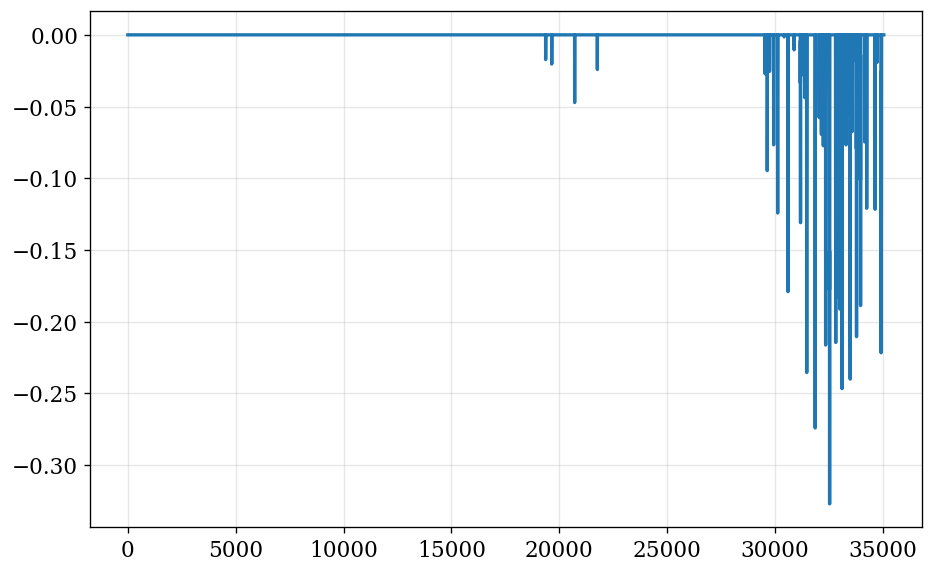

In [17]:
plt.plot(u_star)

In [ ]:
def hosting_capacity_under_depth(C_dyn, lhat, K, mu, tol=1e-10):

    C_dyn = np.asarray(C_dyn, dtype=float)
    lhat = np.asarray(lhat, dtype=float)

    if C_dyn.shape != lhat.shape:
        raise ValueError("C_dyn and lhat must have the same shape.")

    active = (lhat > tol) & np.isfinite(C_dyn)
    if not np.any(active):
        return np.inf, np.zeros_like(lhat), np.array([], dtype=int)

    a = np.full_like(C_dyn, np.inf, dtype=float)   # no-curtail bound
    b = np.full_like(C_dyn, np.inf, dtype=float)   # depth-limited curtail bound

    a[active] = C_dyn[active]

    if mu >= 1.0:
        b[active] = np.inf
    else:
        b[active] = C_dyn[active] / (1.0 - mu)

    candidates = np.unique(np.concatenate([a[active], b[active]]))
    candidates = np.sort(candidates[np.isfinite(candidates)])

    def feasible(C):
        # required curtailment amount at each time
        u_req = np.maximum(0.0, (C - C_dyn) * lhat)

        # per-time depth cap
        depth_ok = np.all(u_req <= mu * C * lhat + tol)

        # max number of interventions
        k_used = np.count_nonzero(u_req > tol)

        return depth_ok and (k_used <= K), u_req

    C_star = 0.0
    u_star = np.zeros_like(lhat)

    for C in candidates:
        ok, u_req = feasible(C)
        if ok:
            C_star = C
            u_star = u_req
        else:
            break

    curtailed_idx = np.where(u_star > tol)[0]
    return C_star, u_star, curtailed_idx

In [24]:
# your existing unconstrained-depth result
C_unconstrained = C_sorted[K]

# depth-limited result
mu = 0
C_depth, u_depth, idx_depth = hosting_capacity_under_depth(C_dyn, lhat, K, mu)

print("Unconstrained depth capacity :", C_unconstrained*S_base)
print("Depth-limited capacity       :", C_depth*S_base)
print("Capacity loss due to depth cap:",
      (C_unconstrained - C_depth)*S_base)

Unconstrained depth capacity : 325.04947557750444
Depth-limited capacity       : 162.72443356963612
Capacity loss due to depth cap: 162.32504200786832


### Optimization

In [ ]:
### Main 

def optimization(
    C_res,
    lhat,
    alpha=0.95,   # CVaR confidence level, not intervention fraction
    mu=0.10,      # tail curtailment cap as fraction of C
    solver="GUROBI",
    verbose=True,
):
    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg = True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    constraints = [
        C * lhat - u <= C_res,     
        s >= u - mu * C * lhat - eta,     # CVaR epigraph
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
        # C <= 1.0, # C cannot exceed feeder limit.
    ]


    prob = cp.Problem(cp.Maximize(C), constraints)
    prob.solve(solver=solver, verbose=verbose)

    result = {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
    }
    return result

In [ ]:
# test

def optimization(
    C_res,
    lhat,
    alpha=0.95,
    mu=0.10,
    lam=1e-4,
    solver="GUROBI",
    verbose=True,
):
    T = len(C_res)

    C = cp.Variable(nonneg=True, name="C")
    u = cp.Variable(T, nonneg=True, name="u")
    eta = cp.Variable(name="eta")
    s = cp.Variable(T, nonneg=True, name="s")

    # penalty should be larger when residual capacity is larger
    Cres_pos = np.maximum(C_res, 0.0)
    w = Cres_pos + 1e-3
    w = w / np.max(w)

    constraints = [
        C * lhat - u <= C_res,
        s >= u - mu * C * lhat - eta,
        eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
    ]

    

    # zeta = C * lhat - u - C_res
    # constraints = [
    #     s >= zeta - eta,
    #     eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= 0,
    #     u <= mu * C*lhat,
    #     # C <= 1.0,
    # ]


    obj = cp.Maximize(C - lam * cp.sum(cp.multiply(w, u)))
    prob = cp.Problem(obj, constraints)
    prob.solve(solver=solver, verbose=verbose)

    return {
        "status": prob.status,
        "objective": None if prob.value is None else float(prob.value),
        "C": None if C.value is None else float(C.value),
        "eta": None if eta.value is None else float(eta.value),
        "u": None if u.value is None else np.asarray(u.value).flatten(),
        "s": None if s.value is None else np.asarray(s.value).flatten(),
        "w": w,
    }

In [44]:
T = len(bus_load_pu)


# candidate interconnection bus
host_bus_number = 13

host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)


alpha = 0.95

# K = 350
# alpha = 1 - K/T  
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
mu = 0.1       # max 10% curtailment per timestamp

res = optimization(
    C_res=C_res,
    lhat=lhat,
    alpha=alpha,
    mu=mu,
    solver="CLARABEL",
    verbose=False,
    lam = 1e-2
)

print("Status:", res["status"])
print("Optimal C:", res["C"])
print("Optimal C in kW:", None if res["C"] is None else res["C"] * S_base)
print("eta:", res["eta"])

Status: optimal
Optimal C: 0.5388623781972982
Optimal C in kW: 233.1990476203572
eta: -0.0010746152746021725


In [45]:
len(res["u"][res["u"] > 1e-4])

74

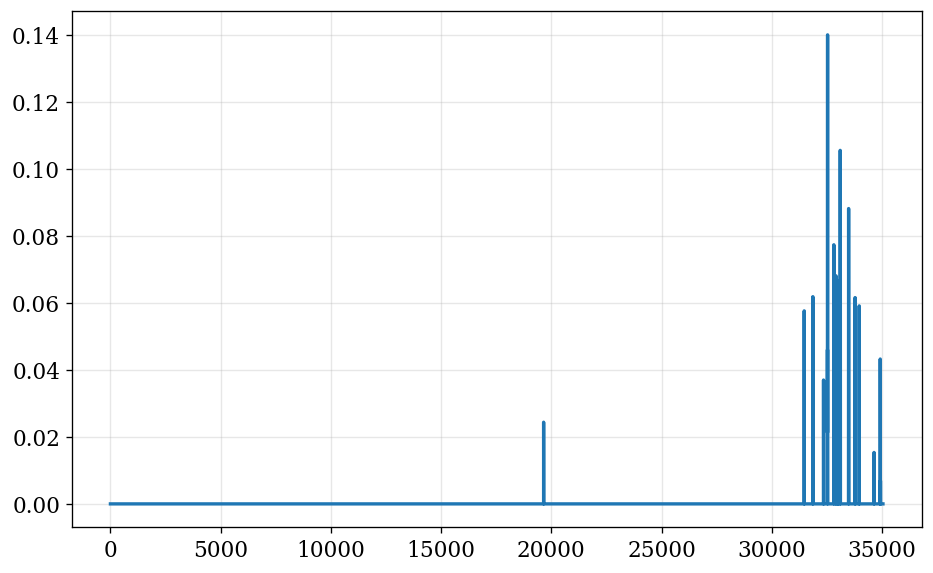

In [46]:
plt.plot(res["u"])

In [65]:
def tune_lambda_for_K(
    C_res,
    lhat,
    K_target,
    alpha=0.95,
    mu=0.1,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL",
    patience = 5
):
    T = len(C_res)
    tol = 1e-6

    best_res = None
    last_K = None
    stagnant_counter = 0

    for i in range(max_iter):
        lam_mid = 0.5 * (lam_low + lam_high)

        res = optimization(
            C_res=C_res,
            lhat=lhat,
            alpha=alpha,
            mu=mu,
            lam=lam_mid,
            solver=solver,
            verbose=False
        )

        if res["status"] not in ["optimal", "optimal_inaccurate"]:
            print("Solver failed at iteration", i)
            break

        u = res["u"]
        K_actual = np.sum(u > tol)

        print(f"Iter {i}: lam={lam_mid:.4e}, K={K_actual}, C={res['C']*S_base:.2f} kW")

        # Store best
        best_res = res

        # early stopping if K is not improving
        if last_K is not None and K_actual == last_K:
            stagnant_counter += 1
        else:
            stagnant_counter = 0

        last_K = K_actual

        if stagnant_counter >= patience:
            print(f"Early stopping: K unchanged for {patience} iterations")
            break

        # Check convergence
        if abs(K_actual - K_target) <= tol_K:
            print("Converged!")
            break

        # Bisection update
        if K_actual > K_target:
            lam_low = lam_mid   # need fewer interventions → increase λ
        else:
            lam_high = lam_mid  # need more interventions → decrease λ

    return best_res, lam_mid

In [73]:
best_res, best_lambda = tune_lambda_for_K(
    C_res=C_res,
    lhat=lhat,
    K_target=350,
    alpha=0.95,
    mu=0.3,
    lam_low=1e-6,
    lam_high=1.0,
    max_iter=30,
    tol_K=5,
    solver="CLARABEL"
)

Iter 0: lam=5.0000e-01, K=9, C=179.85 kW
Iter 1: lam=2.5000e-01, K=18, C=188.29 kW
Iter 2: lam=1.2500e-01, K=34, C=206.24 kW
Iter 3: lam=6.2501e-02, K=62, C=223.01 kW
Iter 4: lam=3.1251e-02, K=117, C=254.97 kW
Iter 5: lam=1.5626e-02, K=230, C=292.58 kW
Iter 6: lam=7.8135e-03, K=453, C=349.94 kW
Iter 7: lam=1.1720e-02, K=305, C=312.27 kW
Iter 8: lam=9.7666e-03, K=363, C=328.73 kW
Iter 9: lam=1.0743e-02, K=332, C=320.62 kW
Iter 10: lam=1.0255e-02, K=348, C=324.81 kW
Converged!


In [76]:
len(best_res["u"][best_res["u"] > 1e-4])

348

In [77]:
best_res['C'] * S_base

np.float64(324.80573871197555)

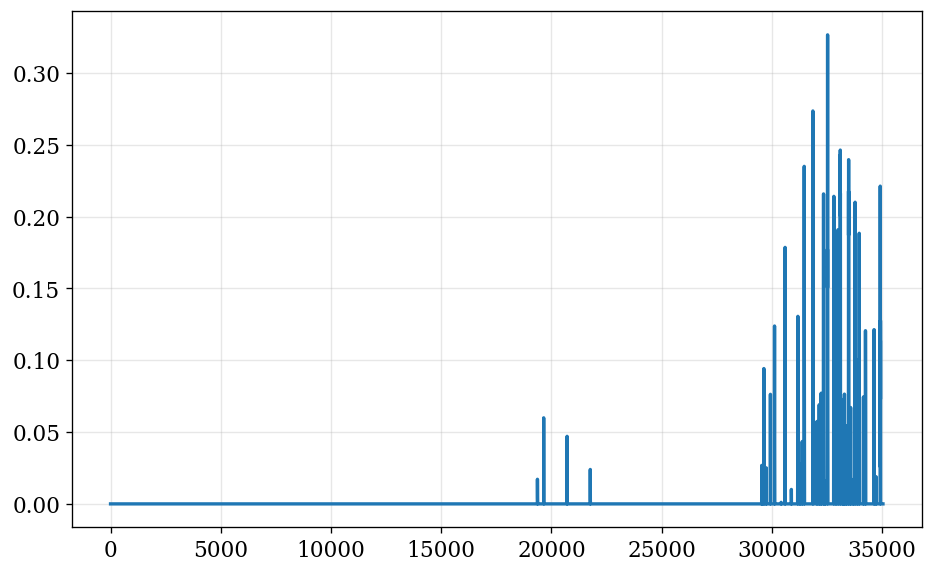

In [78]:
plt.plot(best_res["u"])

array([5.55467835e-13, 5.69384380e-13, 5.60727957e-13, ...,
       4.47701068e-13, 4.46710552e-13, 4.39958535e-13], shape=(35040,))

### Hosting capacity vs. depth

In [ ]:
alpha_vals = np.linspace(0.0, 0.99, 10)   

C_opt = []
C_opt_kw = []
eta_vals = []
status_vals = []

for alpha in alpha_vals:
    res = optimization(
        C_res=C_res,
        lhat=lhat,
        alpha=alpha,
        mu=mu,
        solver="CLARABEL",
        verbose=False,
    )

    status_vals.append(res["status"])
    
    if res["C"] is not None:
        C_opt.append(res["C"])
        C_opt_kw.append(res["C"] * S_base)
        eta_vals.append(res["eta"])
    else:
        C_opt.append(np.nan)
        C_opt_kw.append(np.nan)
        eta_vals.append(np.nan)

# Print values
for a, c, ckw, st in zip(alpha_vals, C_opt, C_opt_kw, status_vals):
    print(f"alpha={a:.2f}, status={st}, C*={c}, C*_kW={ckw}")



### Hosting capacity vs confidence level

In [23]:
alpha_vals = np.linspace(0.0, 0.99, 10)   

C_opt = []
C_opt_kw = []
eta_vals = []
status_vals = []

for alpha in alpha_vals:
    res = optimization(
        C_res=C_res,
        lhat=lhat,
        alpha=alpha,
        mu=mu,
        solver="CLARABEL",
        verbose=False,
    )

    status_vals.append(res["status"])
    
    if res["C"] is not None:
        C_opt.append(res["C"])
        C_opt_kw.append(res["C"] * S_base)
        eta_vals.append(res["eta"])
    else:
        C_opt.append(np.nan)
        C_opt_kw.append(np.nan)
        eta_vals.append(np.nan)

# Print values
for a, c, ckw, st in zip(alpha_vals, C_opt, C_opt_kw, status_vals):
    print(f"alpha={a:.2f}, status={st}, C*={c}, C*_kW={ckw}")



alpha=0.00, status=optimal, C*=0.9999999999986535, C*_kW=432.7617904968308
alpha=0.11, status=optimal, C*=0.9999999999999722, C*_kW=432.76179049740153
alpha=0.22, status=optimal, C*=0.999999999999614, C*_kW=432.76179049724647
alpha=0.33, status=optimal, C*=0.9999999999958308, C*_kW=432.76179049560926
alpha=0.44, status=optimal, C*=0.9999999999866819, C*_kW=432.76179049164995
alpha=0.55, status=optimal, C*=0.9999999992809945, C*_kW=432.76179018625544
alpha=0.66, status=optimal, C*=0.8968171946708813, C*_kW=388.10821491463804
alpha=0.77, status=optimal, C*=0.7752020833539334, C*_kW=335.4778415895734
alpha=0.88, status=optimal, C*=0.6425767070538783, C*_kW=278.0826462765683
alpha=0.99, status=optimal, C*=0.45233656205021944, C*_kW=195.75398050029736


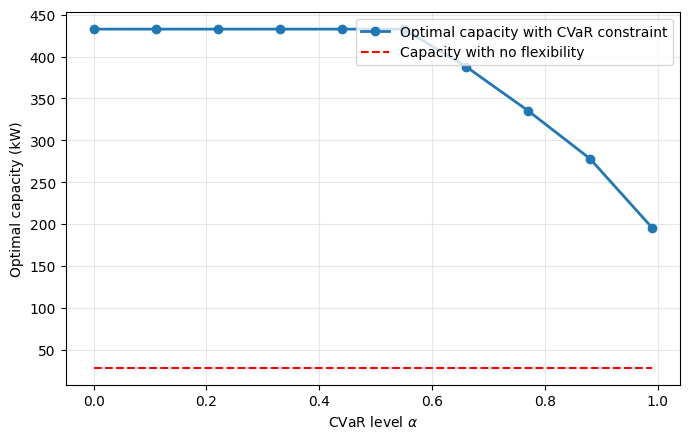

In [44]:
# # Plot in per-unit
# plt.figure(figsize=(7, 4.5))
# plt.plot(alpha_vals, C_opt, marker='o', linewidth=2)
# plt.xlabel(r'Risk parameter $\alpha$')
# plt.ylabel(r'Optimal capacity $C^\star$ (p.u.)')
# plt.title(r'Optimal capacity vs $\alpha$')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# Plot in kW
plt.figure(figsize=(7, 4.5))
plt.plot(alpha_vals, C_opt_kw, marker='o', linewidth=2, label="Optimal capacity with CVaR constraint")
plt.hlines(np.min(C_res * S_base), alpha_vals[0], alpha_vals[-1], color='red', linestyle='--', label="Capacity with no flexibility")
plt.xlabel(r'CVaR level $\alpha$')
plt.ylabel(r'Optimal capacity (kW)')
# plt.title(r'Optimal capacity vs $\alpha$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend(loc = "upper right")
plt.show()

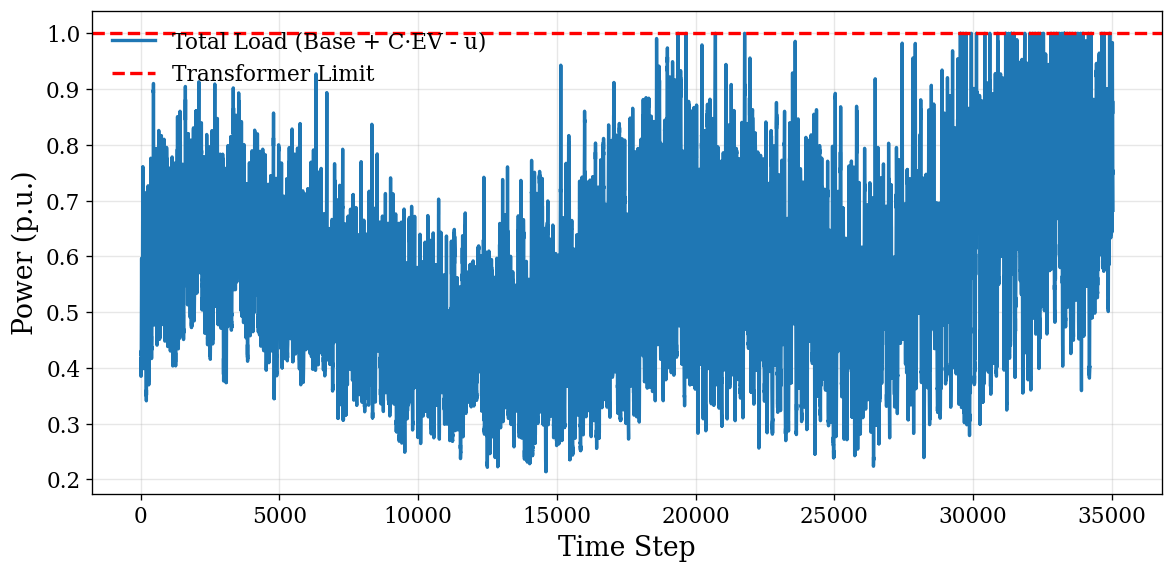

In [83]:
t = np.arange(T)
total_load = bus_load_pu.sum(axis=1) + best_res['C'] * lhat - best_res['u']

limit = 1.0
plt.figure(figsize=(10, 5))
plt.plot(t, total_load, linewidth=2, label="Total Load (Base + C·EV - u)")
plt.axhline(limit, color='red', linestyle='--', linewidth=2, label="Transformer Limit")

plt.xlabel("Time Step")
plt.ylabel("Power (p.u.)")
plt.legend()
plt.show()

Text(0, 0.5, 'Curtailment (p.u.)')

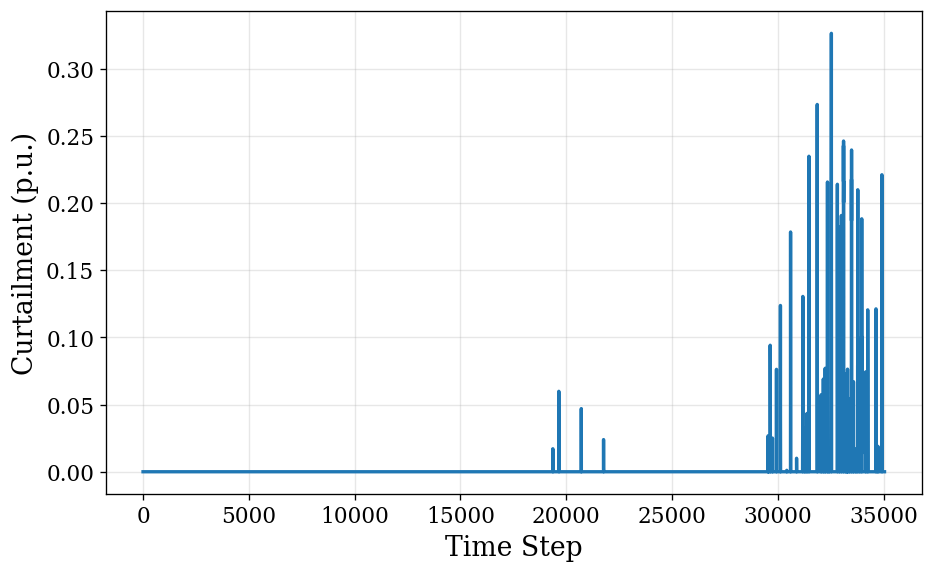

In [84]:
plt.plot(t, best_res['u'], label='Curtailment u')
plt.xlabel("Time Step")
plt.ylabel("Curtailment (p.u.)")

Violation occurs : 97


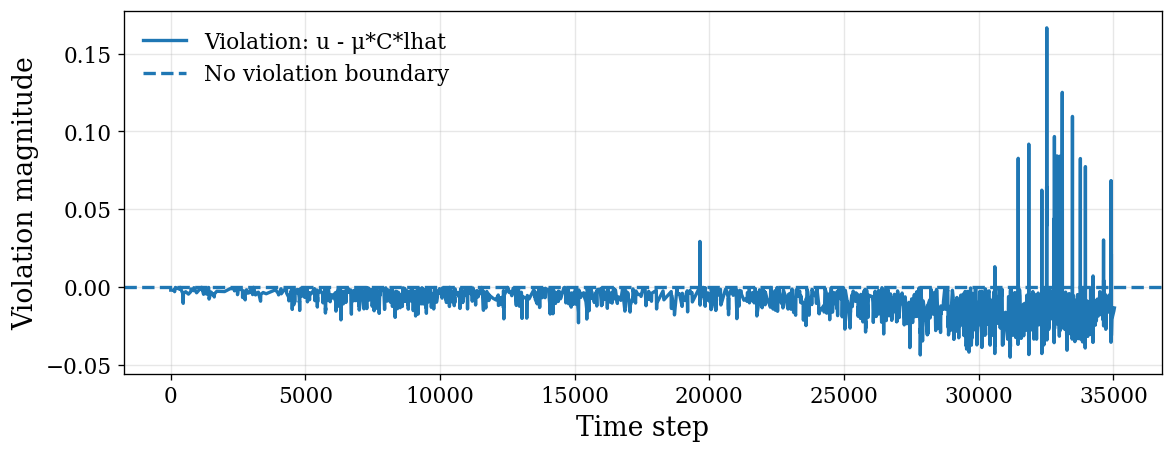

In [72]:
allowed_curt = 0.10 * res["C"] * lhat
violation = best_res["u"] - allowed_curt

violation_idx = np.where(violation > 0)[0]
print ("Violation occurs :", len(violation_idx))

T = len(violation)

plt.figure(figsize=(10, 4))
plt.plot(range(T), violation, linewidth=2, label="Violation: u - μ*C*lhat")
plt.axhline(0, linestyle="--", label="No violation boundary")


plt.xlabel("Time step")
plt.ylabel("Violation magnitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(CVXPY) Mar 27 06:29:32 PM: Your problem has 70082 variables, 70081 constraints, and 0 parameters.
(CVXPY) Mar 27 06:29:32 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 27 06:29:32 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 27 06:29:32 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 27 06:29:32 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 27 06:29:32 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 27 06:29:32 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Mar 27 06:29:32 PM: Applying reduction FlipObjective
(CVXPY) Mar 27 06:29:32 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 27 06:29:32 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 27 06:29:32 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 27 06:29:32 P

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 70082
  constrain

(CVXPY) Mar 27 06:29:37 PM: Problem status: optimal
(CVXPY) Mar 27 06:29:37 PM: Optimal value: 7.410e-01
(CVXPY) Mar 27 06:29:37 PM: Compilation took 1.139e-01 seconds
(CVXPY) Mar 27 06:29:37 PM: Solver (including time spent in interface) took 5.032e+00 seconds
(CVXPY) Mar 27 06:29:37 PM: Your problem has 70082 variables, 70081 constraints, and 0 parameters.
(CVXPY) Mar 27 06:29:37 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 27 06:29:37 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 27 06:29:37 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 27 06:29:37 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 27 06:29:37 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Mar 27 06:29:37 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) 

120  -7.4093e-01  -7.4107e-01  1.31e-04  5.32e-08  3.48e-06  8.28e-10  2.15e-07  8.00e-01  
121  -7.4096e-01  -7.4098e-01  1.60e-05  6.49e-09  4.25e-07  1.01e-10  2.62e-08  9.64e-01  
122  -7.4096e-01  -7.4096e-01  7.29e-07  2.95e-10  1.93e-08  4.58e-12  1.19e-09  9.58e-01  
123  -7.4096e-01  -7.4096e-01  7.38e-09  2.99e-12  1.96e-10  4.64e-14  1.21e-11  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 4.9866953s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
  

(CVXPY) Mar 27 06:29:37 PM: Finished problem compilation (took 1.073e-01 seconds).
(CVXPY) Mar 27 06:29:37 PM: Invoking solver CLARABEL  to obtain a solution.


...

 93  -6.1464e-01  -6.1476e-01  1.18e-04  4.70e-08  2.62e-06  8.10e-10  1.77e-07  7.55e-01  
 94  -6.1466e-01  -6.1467e-01  8.42e-06  3.35e-09  1.87e-07  5.77e-11  1.26e-08  9.80e-01  
 95  -6.1466e-01  -6.1466e-01  8.58e-08  3.41e-11  1.90e-09  5.88e-13  1.29e-10  9.90e-01  
 96  -6.1466e-01  -6.1466e-01  8.67e-10  3.45e-13  1.92e-11  5.91e-15  1.29e-12  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 3.8819758s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
  

(CVXPY) Mar 27 06:29:41 PM: Applying reduction CLARABEL
(CVXPY) Mar 27 06:29:41 PM: Finished problem compilation (took 1.059e-01 seconds).
(CVXPY) Mar 27 06:29:41 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 70082
  constraints   = 140162
  nnz(P)        = 0
  nnz(A)        = 315362
  cones (total) = 1
    : Nonnegative = 1,  numel = 140162

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32
  dynamic reg: on, ϵ = 1.0e-13, δ = 2.0e-7
 

(CVXPY) Mar 27 06:29:44 PM: Problem status: optimal
(CVXPY) Mar 27 06:29:44 PM: Optimal value: 4.523e-01
(CVXPY) Mar 27 06:29:44 PM: Compilation took 1.059e-01 seconds
(CVXPY) Mar 27 06:29:44 PM: Solver (including time spent in interface) took 3.154e+00 seconds


 79  -4.5248e-01  -4.5277e-01  2.88e-04  1.11e-07  4.64e-06  3.85e-09  2.17e-07  4.01e-01  
 80  -4.5237e-01  -4.5244e-01  6.52e-05  2.52e-08  1.05e-06  8.89e-10  4.92e-08  9.90e-01  
 81  -4.5234e-01  -4.5234e-01  1.74e-06  6.72e-10  2.81e-08  2.37e-11  1.31e-09  9.90e-01  
 82  -4.5234e-01  -4.5234e-01  1.74e-08  6.73e-12  2.81e-10  2.37e-13  1.31e-11  9.90e-01  
 83  -4.5234e-01  -4.5234e-01  1.79e-10  6.90e-14  2.87e-12  2.41e-15  1.33e-13  9.90e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 3.1146694s
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


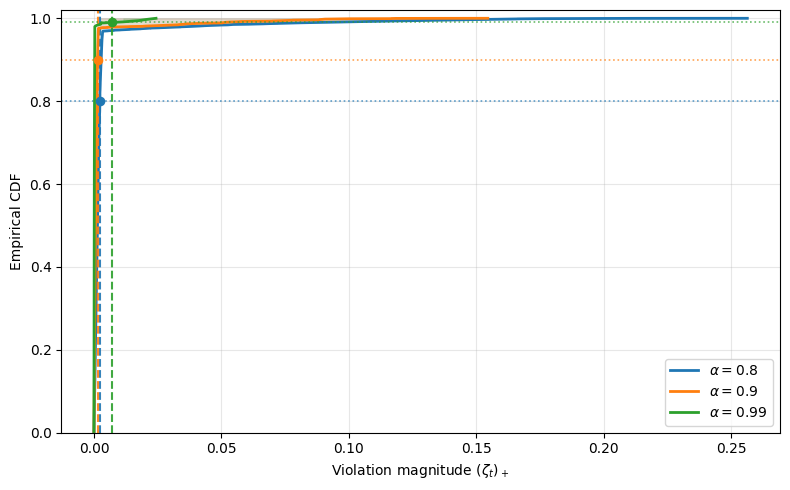

In [ ]:
def empirical_cdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

alphas = [0.8, 0.9, 0.99]

plt.figure(figsize=(8, 5))

for a in alphas:
    res = optimization(
        C_res=C_res,
        lhat=lhat,
        alpha=a,
        mu=mu,
        solver="CLARABEL",
        verbose=True,
    )

    s = res["s"]
    viol = np.maximum(s, 0)
    viol = viol[viol > 1e-8]

    if len(viol) == 0:
        continue

    x, y = empirical_cdf(viol)
    var = np.quantile(viol, a)
    cvar = viol[viol >= var].mean()

    # plot CDF
    line, = plt.plot(x, y, linewidth=2, label=fr'$\alpha={a}$')
    color = line.get_color()

    # horizontal alpha line
    plt.axhline(a, linestyle=':', linewidth=1.2, color=color, alpha=0.7)

    # vertical VaR line
    plt.axvline(var, linestyle='--', linewidth=1.5, color=color, alpha=0.9)

    # intersection point (VaR on CDF)
    plt.scatter([var], [a], color=color, s=35, zorder=4)

    # shade tail region: x >= VaR
    tail_mask = x >= var
    if np.any(tail_mask):
        plt.fill_between(
            x[tail_mask], y[tail_mask], 1.0,
            color=color, alpha=0.15
        )


plt.xlabel(r'Violation magnitude $(\zeta_t)_+$')
plt.ylabel('Empirical CDF')
# plt.title(r'CDF of Positive Violations with VaR and CVaR Tail Region')
plt.ylim(0, 1.02)
plt.x_lim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

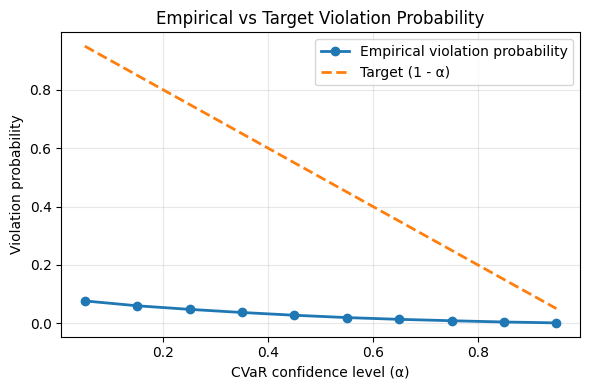

In [17]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.linspace(0.05, 0.95, 10)

empirical = []

for a in alphas:
    res = optimization(C_res, lhat, alpha=a, mu=0.10, verbose=False, solver =  'ClARABEL')

    violation = res["u"] - 0.10 * res["C"] * lhat
    frac = np.mean(violation > 1e-6)

    empirical.append(frac)

# Plot
plt.figure(figsize=(6,4))

plt.plot(alphas, empirical, marker='o', linewidth=2,
         label="Empirical violation probability")

plt.plot(alphas, 1 - alphas, linestyle='--', linewidth=2,
         label="Target (1 - α)")

plt.xlabel("CVaR confidence level (α)")
plt.ylabel("Violation probability")
plt.title("Empirical vs Target Violation Probability")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### CVAR Plot

alpha       = 0.90
VaR_alpha   = 2.3571
CVaR_alpha  = 3.5578


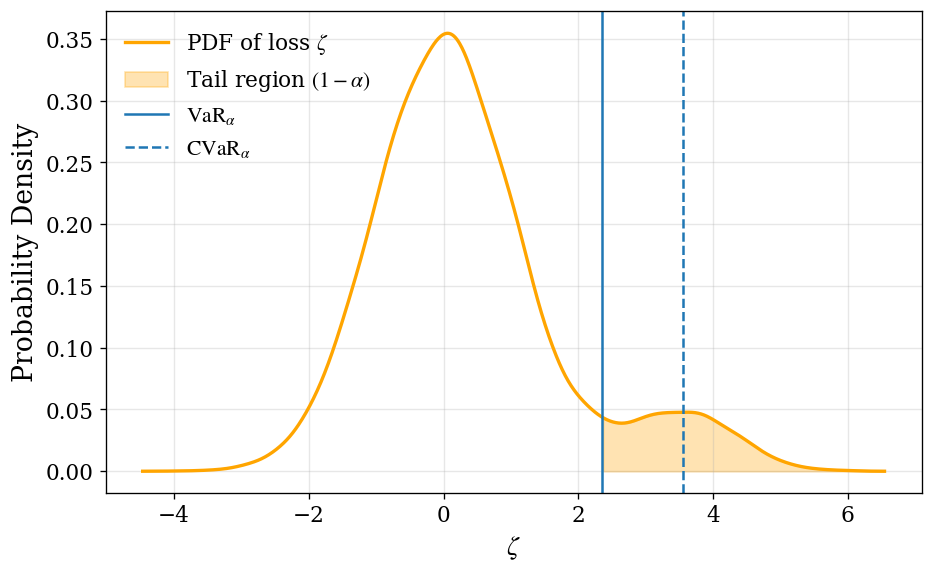

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


np.random.seed(2025)

# Mixture distribution to create a visible heavy right tail
n = 20000
main_part = np.random.normal(loc=0.0, scale=1.0, size=int(0.9 * n))
tail_part = np.random.normal(loc=3.5, scale=0.8, size=int(0.1 * n))
zeta = np.concatenate([main_part, tail_part])

# -----------------------------
# CVaR settings
# -----------------------------
alpha = 0.90

# Value-at-Risk (VaR_alpha): alpha-quantile
var_alpha = np.quantile(zeta, alpha)

# Conditional Value-at-Risk (CVaR_alpha): mean of tail beyond VaR
tail_losses = zeta[zeta >= var_alpha]
cvar_alpha = tail_losses.mean()

print(f"alpha       = {alpha:.2f}")
print(f"VaR_alpha   = {var_alpha:.4f}")
print(f"CVaR_alpha  = {cvar_alpha:.4f}")

# -----------------------------
# Density estimation for smooth PDF
# -----------------------------
x = np.linspace(zeta.min() - 0.5, zeta.max() + 0.5, 1000)
kde = gaussian_kde(zeta)
pdf = kde(x)

# Tail region for shading
tail_mask = x >= var_alpha

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 5))

# PDF curve
plt.plot(x, pdf, linewidth=2, color = 'orange', label=r'PDF of loss $\zeta$')

# Shade tail region beyond VaR
plt.fill_between(
    x[tail_mask], pdf[tail_mask], 0,
    alpha=0.3,
    color = 'orange',
    label=rf'Tail region $(1-\alpha)$'
)

# VaR vertical line
plt.axvline(
    var_alpha, linestyle='-', linewidth=1.5,
    label=rf'$\mathrm{{VaR}}_{{\alpha}}$'
)

# CVaR vertical line
plt.axvline(
    cvar_alpha, linestyle='--', linewidth=1.5,
    label=rf'$\mathrm{{CVaR}}_{{\alpha}}$'
)

plt.xlabel(r'$\zeta$')
plt.ylabel('Probability Density')
plt.legend(loc= 'upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()